In [1]:
from pathlib import Path
import os
import sys
import subprocess

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

PROJECT_ROOT = Path.cwd().resolve()

if not (PROJECT_ROOT / "quran_asr").exists() or not (PROJECT_ROOT / "configs").exists():
    raise RuntimeError(
        f"Notebook harus dijalankan dari root project.\n"
        f"Posisi sekarang: {PROJECT_ROOT}"
    )

CONFIG_PATH = PROJECT_ROOT / "configs" / "local_3050.yaml"

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Config belum ada: {CONFIG_PATH}")

CACHE_DIR = PROJECT_ROOT / ".cache" / "hf"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(CACHE_DIR)
os.environ["HF_HUB_CACHE"] = str(CACHE_DIR / "hub")
os.environ["TRANSFORMERS_CACHE"] = str(CACHE_DIR / "transformers")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CONFIG_PATH:", CONFIG_PATH)
print("HF_HOME:", os.environ["HF_HOME"])
print("Python:", sys.executable)

PROJECT_ROOT: /home/jrilym/Projects/AI/model-asr-quran
CONFIG_PATH: /home/jrilym/Projects/AI/model-asr-quran/configs/local_3050.yaml
HF_HOME: /home/jrilym/Projects/AI/model-asr-quran/.cache/hf
Python: /home/jrilym/Projects/AI/model-asr-quran/.venv/bin/python


In [2]:
def run_cmd(args):
    print("Running:")
    print(" ".join(str(arg) for arg in args))
    subprocess.run(args, check=True, cwd=PROJECT_ROOT)

In [3]:
RAW_AUDIO_DIR = PROJECT_ROOT / "data" / "raw" / "audio"
RAW_TEXT_FILE = PROJECT_ROOT / "data" / "raw" / "text" / "quran_uthmani.json"

if not RAW_AUDIO_DIR.exists() or not any(RAW_AUDIO_DIR.iterdir()):
    raise RuntimeError(f"Audio belum ada di: {RAW_AUDIO_DIR}")

if not RAW_TEXT_FILE.exists():
    raise FileNotFoundError(f"Text Quran belum ada: {RAW_TEXT_FILE}")

audio_files = list(RAW_AUDIO_DIR.rglob("*.*"))

print("Raw audio OK:", RAW_AUDIO_DIR)
print("Jumlah audio:", len(audio_files))
print("Quran text OK:", RAW_TEXT_FILE)

print("\nContoh audio:")
for file in audio_files[:5]:
    print("-", file.relative_to(PROJECT_ROOT))

Raw audio OK: /home/jrilym/Projects/AI/model-asr-quran/data/raw/audio
Jumlah audio: 24946
Quran text OK: /home/jrilym/Projects/AI/model-asr-quran/data/raw/text/quran_uthmani.json

Contoh audio:
- data/raw/audio/Husary_128kbps_Mujawwad/001003.mp3
- data/raw/audio/Husary_128kbps_Mujawwad/001003.md5
- data/raw/audio/Husary_128kbps_Mujawwad/001002.mp3
- data/raw/audio/Husary_128kbps_Mujawwad/001002.md5
- data/raw/audio/Husary_128kbps_Mujawwad/001001.mp3


In [4]:
run_cmd([
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "build.py"),
    "--config",
    str(CONFIG_PATH),
])

Running:
/home/jrilym/Projects/AI/model-asr-quran/.venv/bin/python /home/jrilym/Projects/AI/model-asr-quran/scripts/build.py --config /home/jrilym/Projects/AI/model-asr-quran/configs/local_3050.yaml


Saving the dataset (1/1 shards): 100%|██████████| 199/199 [00:00<00:00, 67655.55 examples/s]
  train: 1611 rows
  validation: 165 rows
  test: 199 rows
[build] saved DatasetDict to data/processed


In [5]:
run_cmd([
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "build_vocab.py"),
    "--config",
    str(CONFIG_PATH),
])

Running:
/home/jrilym/Projects/AI/model-asr-quran/.venv/bin/python /home/jrilym/Projects/AI/model-asr-quran/scripts/build_vocab.py --config /home/jrilym/Projects/AI/model-asr-quran/configs/local_3050.yaml
{
 "َ": 0,
 "ِ": 1,
 "ْ": 2,
 "ل": 3,
 "ُ": 4,
 "ن": 5,
 "م": 6,
 "ا": 7,
 "و": 8,
 "ّ": 9,
 "ي": 10,
 "ر": 11,
 "ٱ": 12,
 "ه": 13,
 "ب": 14,
 "ك": 15,
 "ٰ": 16,
 "ت": 17,
 "ع": 18,
 "ف": 19,
 "أ": 20,
 "ق": 21,
 "ى": 22,
 "س": 23,
 "د": 24,
 "إ": 25,
 "ذ": 26,
 "ح": 27,
 "ٓ": 28,
 "ٍ": 29,
 "ج": 30,
 "ً": 31,
 "ٌ": 32,
 "ص": 33,
 "خ": 34,
 "ة": 35,
 "ء": 36,
 "ز": 37,
 "ش": 38,
 "ط": 39,
 "ث": 40,
 "غ": 41,
 "ض": 42,
 "ئ": 43,
 "ظ": 44,
 "ٔ": 45,
 "ؤ": 46,
 "|": 47,
 "[UNK]": 48,
 "[PAD]": 49
}


[vocab] 50 tokens from dataset(train+validation) (1776 texts) -> data/artifacts/vocab.json


In [6]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
VOCAB_PATH = PROJECT_ROOT / "data" / "artifacts" / "vocab.json"

print("Processed dir:", PROCESSED_DIR, "OK" if PROCESSED_DIR.exists() else "MISSING")
print("Vocab path:", VOCAB_PATH, "OK" if VOCAB_PATH.exists() else "MISSING")

print("\nIsi data/processed:")
if PROCESSED_DIR.exists():
    for path in sorted(PROCESSED_DIR.rglob("*"))[:50]:
        print("-", path.relative_to(PROJECT_ROOT))

Processed dir: /home/jrilym/Projects/AI/model-asr-quran/data/processed OK
Vocab path: /home/jrilym/Projects/AI/model-asr-quran/data/artifacts/vocab.json OK

Isi data/processed:
- data/processed/dataset_dict.json
- data/processed/test
- data/processed/test/cache-2104c9c23f1319f3.arrow
- data/processed/test/cache-9d88e28de32a507d.arrow
- data/processed/test/cache-a13591b069964ba2.arrow
- data/processed/test/cache-c88ec2bdbd80a326.arrow
- data/processed/test/data-00000-of-00001.arrow
- data/processed/test/dataset_info.json
- data/processed/test/state.json
- data/processed/train
- data/processed/train/cache-07bd9501f34472b0.arrow
- data/processed/train/cache-4fcd92e88f7864e2.arrow
- data/processed/train/cache-bf257d5982d0baa5.arrow
- data/processed/train/cache-efecaaca69f9cb90.arrow
- data/processed/train/data-00000-of-00001.arrow
- data/processed/train/dataset_info.json
- data/processed/train/state.json
- data/processed/train/tmpbsdo7666
- data/processed/validation
- data/processed/valida

In [7]:
import json
import math
import random
import numpy as np

import torch
import gc

torch.cuda.empty_cache()
gc.collect()

from pathlib import Path
from datasets import load_from_disk, DatasetDict
from transformers import (
    Wav2Vec2ForCTC,
    Wav2Vec2Processor,
    Wav2Vec2CTCTokenizer,
    Wav2Vec2FeatureExtractor,
    get_linear_schedule_with_warmup,
)

from torch.utils.data import DataLoader
from tqdm.auto import tqdm

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

/home/jrilym/Projects/AI/model-asr-quran/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.12.1+cu130
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [8]:
import yaml

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

cfg

{'run_name': 'husary_mujawwad_local_3050_small_v1',
 'seed': 42,
 'data': {'reciters': ['Husary_128kbps_Mujawwad'],
  'audio_dir': 'data/raw/audio',
  'text_path': 'data/raw/text/quran_uthmani.json',
  'processed_dir': 'data/processed',
  'sample_rate': 16000,
  'surahs': 'all',
  'max_duration_sec': 20,
  'split': {'strategy': 'by_surah',
   'test_surahs': [78, 79, 80, 81, 82, 93, 109, 110, 112, 113, 114],
   'val_surahs': [88, 89, 90, 91, 92, 94, 95, 96, 97, 98, 99, 100],
   'val_frac_within_train': 0.05}},
 'model': {'base': 'facebook/wav2vec2-xls-r-300m',
  'vocab_path': 'data/artifacts/vocab.json',
  'freeze_feature_encoder_steps': 0,
  'apply_spec_augment': False},
 'training': {'epochs': 10,
  'per_device_train_batch_size': 1,
  'per_device_eval_batch_size': 1,
  'gradient_accumulation_steps': 16,
  'learning_rate': 1e-05,
  'warmup_ratio': 0.03,
  'weight_decay': 0.0,
  'gradient_checkpointing': True,
  'fp16': True,
  'masking_time_prob': 0.05,
  'eval_steps': 500,
  'save_ste

In [9]:
from datasets import load_from_disk, DatasetDict

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Coba format DatasetDict langsung
if (PROCESSED_DIR / "dataset_dict.json").exists():
    dataset = load_from_disk(str(PROCESSED_DIR))

# Coba format split folder: train/validation/test atau train/val/test
elif (PROCESSED_DIR / "train").exists():
    split_map = {}

    for split_name in ["train", "validation", "val", "test"]:
        split_dir = PROCESSED_DIR / split_name
        if split_dir.exists():
            key = "validation" if split_name == "val" else split_name
            split_map[key] = load_from_disk(str(split_dir))

    dataset = DatasetDict(split_map)

else:
    raise RuntimeError(
        f"Format processed dataset belum dikenali di: {PROCESSED_DIR}\n"
        "Cek output scripts/build.py dulu."
    )

dataset

DatasetDict({
    train: Dataset({
        features: ['audio_path', 'text', 'text_plain', 'surah', 'ayah', 'reciter', 'duration'],
        num_rows: 1611
    })
    validation: Dataset({
        features: ['audio_path', 'text', 'text_plain', 'surah', 'ayah', 'reciter', 'duration'],
        num_rows: 165
    })
    test: Dataset({
        features: ['audio_path', 'text', 'text_plain', 'surah', 'ayah', 'reciter', 'duration'],
        num_rows: 199
    })
})

In [10]:
print(dataset)

for split in dataset.keys():
    print("\nSPLIT:", split)
    print("Columns:", dataset[split].column_names)
    print("Rows:", len(dataset[split]))
    print("Sample:")
    print(dataset[split][0])
    break

DatasetDict({
    train: Dataset({
        features: ['audio_path', 'text', 'text_plain', 'surah', 'ayah', 'reciter', 'duration'],
        num_rows: 1611
    })
    validation: Dataset({
        features: ['audio_path', 'text', 'text_plain', 'surah', 'ayah', 'reciter', 'duration'],
        num_rows: 165
    })
    test: Dataset({
        features: ['audio_path', 'text', 'text_plain', 'surah', 'ayah', 'reciter', 'duration'],
        num_rows: 199
    })
})

SPLIT: train
Columns: ['audio_path', 'text', 'text_plain', 'surah', 'ayah', 'reciter', 'duration']
Rows: 1611
Sample:
{'audio_path': 'data/raw/audio/Husary_128kbps_Mujawwad/077016.mp3', 'text': 'أَلَمْ نُهْلِكِ ٱلْأَوَّلِينَ', 'text_plain': 'ألم نهلك ٱلأولين', 'surah': 77, 'ayah': 16, 'reciter': 'Husary_128kbps_Mujawwad', 'duration': 11.546125}


In [11]:
VOCAB_PATH = PROJECT_ROOT / "data" / "artifacts" / "vocab.json"

if not VOCAB_PATH.exists():
    raise FileNotFoundError(f"Vocab belum ada: {VOCAB_PATH}")

tokenizer = Wav2Vec2CTCTokenizer(
    str(VOCAB_PATH),
    unk_token="[UNK]",
    pad_token="[PAD]",
    word_delimiter_token="|",
)

feature_extractor = Wav2Vec2FeatureExtractor(
    feature_size=1,
    sampling_rate=cfg["data"]["sample_rate"],
    padding_value=0.0,
    do_normalize=True,
    return_attention_mask=True,
)

processor = Wav2Vec2Processor(
    feature_extractor=feature_extractor,
    tokenizer=tokenizer,
)

print("Processor OK")
print("Vocab size:", len(processor.tokenizer))

Processor OK
Vocab size: 52


In [12]:
sample_split = "train" if "train" in dataset else list(dataset.keys())[0]
columns = dataset[sample_split].column_names

audio_candidates = ["audio", "audio_path", "path", "file", "file_path", "input_path"]
text_candidates = ["text", "sentence", "transcript", "transcription", "target", "label"]

audio_col = next((c for c in audio_candidates if c in columns), None)
text_col = next((c for c in text_candidates if c in columns), None)

print("Columns:", columns)
print("Detected audio_col:", audio_col)
print("Detected text_col:", text_col)

if audio_col is None:
    raise RuntimeError("Kolom audio tidak ketemu. Lihat output columns di atas.")

if text_col is None:
    raise RuntimeError("Kolom text/transcript tidak ketemu. Lihat output columns di atas.")

Columns: ['audio_path', 'text', 'text_plain', 'surah', 'ayah', 'reciter', 'duration']
Detected audio_col: audio_path
Detected text_col: text


In [13]:
import librosa

SAMPLE_RATE = cfg["data"]["sample_rate"]

def prepare_batch(batch):
    audio_value = batch[audio_col]

    # Kalau audio sudah berupa dict dari datasets Audio
    if isinstance(audio_value, dict) and "array" in audio_value:
        speech_array = audio_value["array"]
        sampling_rate = audio_value.get("sampling_rate", SAMPLE_RATE)

        if sampling_rate != SAMPLE_RATE:
            speech_array = librosa.resample(
                speech_array,
                orig_sr=sampling_rate,
                target_sr=SAMPLE_RATE,
            )

    # Kalau audio berupa path string
    else:
        audio_path = Path(audio_value)

        if not audio_path.is_absolute():
            audio_path = PROJECT_ROOT / audio_path

        speech_array, _ = librosa.load(str(audio_path), sr=SAMPLE_RATE)

    inputs = processor(
        speech_array,
        sampling_rate=SAMPLE_RATE,
    )

    batch["input_values"] = inputs.input_values[0]
    batch["attention_mask"] = inputs.attention_mask[0] if "attention_mask" in inputs else None

    labels = processor.tokenizer(batch[text_col]).input_ids
    batch["labels"] = labels

    return batch

In [14]:
remove_columns = dataset[sample_split].column_names

prepared_dataset = dataset.map(
    prepare_batch,
    remove_columns=remove_columns,
    num_proc=1,
)

prepared_dataset

DatasetDict({
    train: Dataset({
        features: ['input_values', 'attention_mask', 'labels'],
        num_rows: 1611
    })
    validation: Dataset({
        features: ['input_values', 'attention_mask', 'labels'],
        num_rows: 165
    })
    test: Dataset({
        features: ['input_values', 'attention_mask', 'labels'],
        num_rows: 199
    })
})

In [15]:
class DataCollatorCTCWithPadding:
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, features):
        input_features = [
            {"input_values": feature["input_values"]}
            for feature in features
        ]

        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]

        batch = self.processor.pad(
            input_features,
            padding=True,
            return_tensors="pt",
        )

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            padding=True,
            return_tensors="pt",
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100,
        )

        batch["labels"] = labels

        return batch

data_collator = DataCollatorCTCWithPadding(processor)

In [16]:
train_batch_size = cfg["training"]["per_device_train_batch_size"]
eval_batch_size = cfg["training"]["per_device_eval_batch_size"]

train_loader = DataLoader(
    prepared_dataset["train"],
    batch_size=train_batch_size,
    shuffle=True,
    collate_fn=data_collator,
)

eval_split = "validation" if "validation" in prepared_dataset else "val" if "val" in prepared_dataset else "test"

eval_loader = DataLoader(
    prepared_dataset[eval_split],
    batch_size=eval_batch_size,
    shuffle=False,
    collate_fn=data_collator,
)

print("Train batches:", len(train_loader))
print("Eval split:", eval_split)
print("Eval batches:", len(eval_loader))

Train batches: 1611
Eval split: validation
Eval batches: 165


In [17]:
import torch
import gc
from transformers import Wav2Vec2ForCTC

torch.cuda.empty_cache()
gc.collect()

base_model = cfg["model"]["base"]

In [18]:
OUTPUT_DIR = PROJECT_ROOT / cfg["logging"]["output_dir"]
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR)

OUTPUT_DIR: /home/jrilym/Projects/AI/model-asr-quran/data/artifacts/checkpoints/local_3050_small


In [19]:
stage_keys = [
    "auto_stage",
    "bootstrap_min_epochs",
    "bootstrap_max_epochs",
    "bootstrap_head_learning_rate",
    "bootstrap_blank_logit_bias_init",
    "finetune_encoder_trainable_layers",
    "finetune_encoder_learning_rate",
    "finetune_head_learning_rate",
]
print("Manual trainer recipe:")
for key in stage_keys:
    print(f"{key}:", cfg["training"].get(key))

run_cmd([
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "train_manual.py"),
    "--config",
    str(CONFIG_PATH),
    "--no-resume",
])


Manual trainer recipe:
auto_stage: True
bootstrap_min_epochs: 3
bootstrap_max_epochs: 4
bootstrap_head_learning_rate: 0.0007
bootstrap_blank_logit_bias_init: -2.0
finetune_encoder_trainable_layers: 1
finetune_encoder_learning_rate: 5e-07
finetune_head_learning_rate: 0.0003
Running:
/home/jrilym/Projects/AI/model-asr-quran/.venv/bin/python /home/jrilym/Projects/AI/model-asr-quran/scripts/train_manual.py --config /home/jrilym/Projects/AI/model-asr-quran/configs/local_3050.yaml --no-resume


Loading weights: 100%|██████████| 422/422 [00:00<00:00, 63919.55it/s]
[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     | 
-----------------------------+------------+-
project_q.bias               | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
lm_head.weight               | MISSING    | 
lm_head.bias                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Initial blank logit bias adjusted by -2.00
No resume checkpoint found. Starting fresh.
Model: facebook/wav2vec2-xls-r-300m
Trainable encoder layers: 0
Trainable params: 53300
Total params: 315492020
Trainable ratio: 0.0169 %
epoch     stage   step     train      eval    WERp    CERp    WERd    CERd   empty  best


Epoch 1/10:  29%|██▊       | 460/1611 [01:55<04:48,  3.99it/s, loss=64.5, step=28]
Traceback (most recent call last):
  File "/home/jrilym/Projects/AI/model-asr-quran/scripts/train_manual.py", line 37, in <module>
    raise SystemExit(main())
                     ^^^^^^
  File "/home/jrilym/Projects/AI/model-asr-quran/scripts/train_manual.py", line 24, in main
    result = train_manual(
             ^^^^^^^^^^^^^
  File "/home/jrilym/Projects/AI/model-asr-quran/quran_asr/training/manual_train.py", line 158, in train_manual
    train_loss, global_step = _train_one_epoch(
                              ^^^^^^^^^^^^^^^^^
  File "/home/jrilym/Projects/AI/model-asr-quran/quran_asr/training/manual_train.py", line 415, in _train_one_epoch
    outputs = model(**batch)
              ^^^^^^^^^^^^^^
  File "/home/jrilym/Projects/AI/model-asr-quran/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1778, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           

KeyboardInterrupt: 

In [ ]:
import torch
from transformers import Wav2Vec2ForCTC

from quran_asr.tokenizer.processor import build_processor
from quran_asr.audio_io import load_audio

checkpoint_dir = OUTPUT_DIR / "latest"
processor = build_processor(cfg["model"]["vocab_path"], cfg["data"]["sample_rate"])

model = Wav2Vec2ForCTC.from_pretrained(checkpoint_dir).to(device)
model.eval()

sample = dataset["validation"][0]
audio, sr = load_audio(sample["audio_path"], cfg["data"]["sample_rate"])
inputs = processor(audio, sampling_rate=sr, return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    logits = model(**inputs).logits[0]
    probs = torch.softmax(logits, dim=-1)

pred_ids = torch.argmax(logits, dim=-1)
pred_text = processor.batch_decode(pred_ids.unsqueeze(0))[0]

blank_id = processor.tokenizer.pad_token_id
blank_rate = (pred_ids == blank_id).float().mean().item()
top_ids = probs.mean(dim=0).topk(10).indices.tolist()
id_to_token = processor.tokenizer.convert_ids_to_tokens(top_ids)

print("PRED:", repr(pred_text))
print("TARGET:", sample["text"])
print("blank_id:", blank_id)
print("blank frame rate:", blank_rate)
print("top avg tokens:")
for i, tok in zip(top_ids, id_to_token):
    print(i, repr(tok), float(probs[:, i].mean()))

Loading weights: 100%|██████████| 424/424 [00:00<00:00, 2466.85it/s]


PRED: 'ا'
TARGET: هَلْ أَتَىٰكَ حَدِيثُ ٱلْغَٰشِيَةِ
blank_id: 49
blank frame rate: 0.0
top avg tokens:
7 'ا' 0.7220138907432556
3 'ل' 0.2045266181230545
0 'َ' 0.042842790484428406
6 'م' 0.007704564835876226
47 '|' 0.003475147532299161
1 'ِ' 0.002510931808501482
2 'ْ' 0.002253767801448703
4 'ُ' 0.0018598194001242518
9 'ّ' 0.0012402184074744582
5 'ن' 0.0011784913949668407


### Catatan checkpoint

Untuk inspeksi saat training belum selesai, gunakan `OUTPUT_DIR / "latest"`. `final/` baru valid setelah training selesai normal dan disalin dari checkpoint terbaik.


,epoch,global_step,train_loss,eval_loss,wer,cer,wer_plain,cer_plain,empty_pred_rate
0,1,101,38.492691,17.596079,1.0,0.944340,0.995114,0.902039,0.0
1,2,202,23.509855,17.440913,1.0,0.950189,0.993485,0.912070,0.0
2,3,303,23.269059,17.290437,1.0,0.976981,1.000000,0.959211,0.0
3,4,404,22.958508,17.065458,1.0,0.977170,1.000000,0.959545,0.0


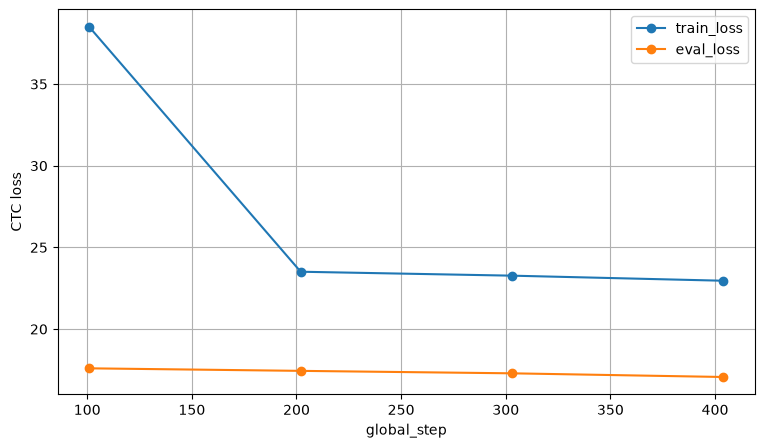

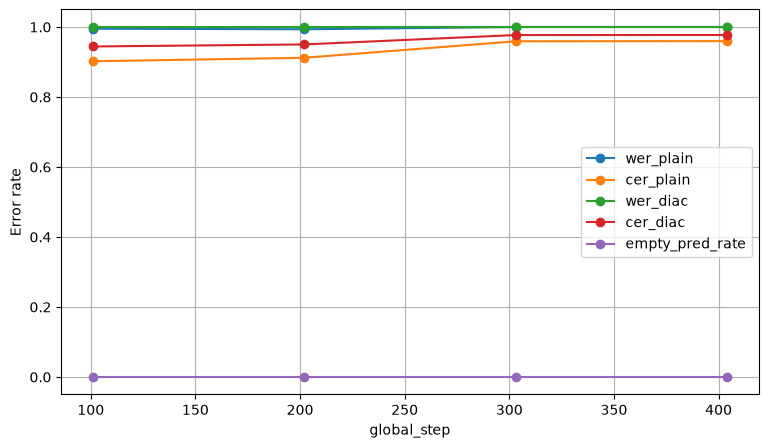

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

history_path = OUTPUT_DIR / "latest" / "training_history.json"
history = json.loads(history_path.read_text())
df = pd.DataFrame(history)

display(df)

if "stage" in df.columns:
    display(df.groupby("stage", dropna=False)[["epoch", "global_step"]].agg(["min", "max", "count"]))

x = "global_step" if "global_step" in df.columns else "epoch"

plt.figure(figsize=(9, 5))
plt.plot(df[x], df["train_loss"], marker="o", label="train_loss")
plt.plot(df[x], df["eval_loss"], marker="o", label="eval_loss")
plt.xlabel(x)
plt.ylabel("CTC loss")
plt.grid(True)
plt.legend()
plt.show()

metric_cols = {"wer_plain", "cer_plain", "wer", "cer"}
if metric_cols.issubset(df.columns):
    plt.figure(figsize=(9, 5))
    plt.plot(df[x], df["wer_plain"], marker="o", label="wer_plain")
    plt.plot(df[x], df["cer_plain"], marker="o", label="cer_plain")
    plt.plot(df[x], df["wer"], marker="o", label="wer_diac")
    plt.plot(df[x], df["cer"], marker="o", label="cer_diac")

    if "empty_pred_rate" in df.columns:
        plt.plot(df[x], df["empty_pred_rate"], marker="o", label="empty_pred_rate")

    plt.xlabel(x)
    plt.ylabel("Error rate")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("History ini format lama, belum ada WER/CER columns.")


In [ ]:
import pandas as pd

df_history = pd.DataFrame(history)
csv_path = OUTPUT_DIR / "latest" / "training_history.csv"

df_history.to_csv(csv_path, index=False)

print("CSV saved to:", csv_path)
df_history
